# Week 10 – Simple Deep Learning Mini Project
## MNIST Handwritten Digit Classifier

Following a beginner-friendly PyTorch image classification tutorial. Goal: understand each part of the code at a high level, not optimize it. MNIST is 70,000 grayscale images of handwritten digits (0–9), each 28x28 pixels — the classic "hello world" of deep learning.

In [2]:
!pip install torchvision

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 10.2 MB/s  0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples: 10000


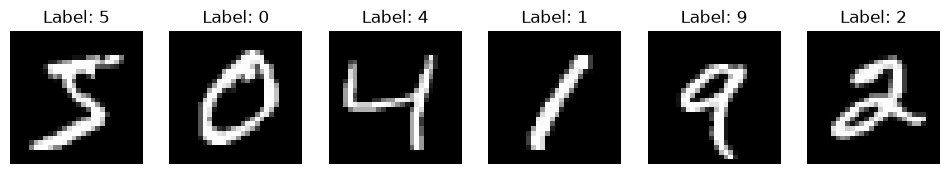

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    image, label = train_data[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.show()

In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)

Batch shape: torch.Size([64, 1, 28, 28])


### Observation
Each image is 28x28 pixels, in grayscale (1 color channel). A batch of 64 images has shape [64, 1, 28, 28]. Data loaders feed the model small batches at a time instead of the whole dataset at once — this is standard practice for training efficiency.

### Day 2: Building a Simple CNN

A Convolutional Neural Network (CNN) is well-suited for images — it uses small filters that slide across the image to detect patterns like edges and shapes, before passing the result to fully connected layers for classification.

In [6]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
